In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


In [2]:
pip install wordCloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Mahesh
[nltk_data]     Jagtap\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Mahesh
[nltk_data]     Jagtap\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
columns = ['sentiment','id','date','flag','user','text']
df = pd.read_csv(
    "Sentiment dataset.csv",
    encoding='latin-1',
    names=columns
)

df.head()

,sentiment,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.head()

,sentiment,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
df = df[['sentiment', 'text']]
df.head()

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [7]:
print(df.shape)

df['sentiment'].value_counts()

(1600000, 2)


sentiment
0    800000
4    800000
Name: count, dtype: int64

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags symbol
    text = re.sub(r'#', '', text)

    # Remove special chars
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

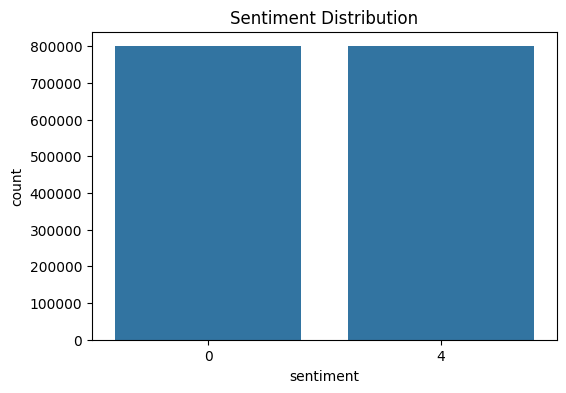

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [10]:
from collections import Counter

positive_words = " ".join(
    df[df['sentiment']==4]['clean_text']
).split()

negative_words = " ".join(
    df[df['sentiment']==0]['clean_text']
).split()

print("Top Positive Words")
print(Counter(positive_words).most_common(20))

print("\nTop Negative Words")
print(Counter(negative_words).most_common(20))

Top Positive Words
[('im', 75272), ('good', 60938), ('day', 53973), ('love', 49509), ('u', 38199), ('get', 38094), ('like', 37947), ('thanks', 33823), ('lol', 33511), ('time', 33198), ('going', 30653), ('go', 29814), ('today', 29222), ('got', 27801), ('one', 27568), ('new', 26645), ('know', 26397), ('see', 25585), ('great', 24892), ('well', 24606)]

Top Negative Words
[('im', 103129), ('day', 50062), ('get', 47840), ('go', 47635), ('work', 45572), ('dont', 45158), ('cant', 43773), ('like', 41150), ('today', 36899), ('want', 34033), ('going', 33451), ('got', 33102), ('back', 32592), ('miss', 31737), ('really', 31230), ('time', 30602), ('u', 29188), ('still', 28781), ('good', 28597), ('one', 28316)]


In [11]:
X = df['clean_text']
y = df['sentiment']

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.77323125
              precision    recall  f1-score   support

           0       0.78      0.75      0.77    159494
           4       0.76      0.79      0.78    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



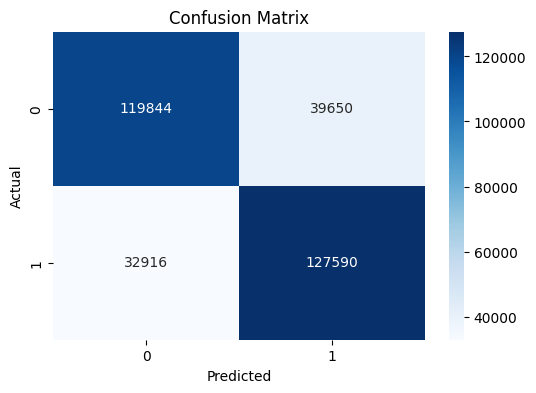

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print(classification_report(
    y_test,
    nb_pred
))

Accuracy: 0.757865625
              precision    recall  f1-score   support

           0       0.75      0.77      0.76    159494
           4       0.76      0.75      0.76    160506

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000



In [16]:
def predict_sentiment(tweet):

    cleaned = clean_text(tweet)

    vector = vectorizer.transform([cleaned])

    prediction = lr_model.predict(vector)[0]

    if prediction == 0:
        return "Negative"

    elif prediction == 4:
        return "Positive"



tweet = "I love this new phone!"

print(predict_sentiment(tweet))

Positive


In [25]:
import re
import joblib

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

lr_model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vector = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vector)[0]

    if prediction == 0:
        return "Negative"
    elif prediction == 4:
        return "Positive"
    else:
        return "Neutral"

In [26]:
tweet = "the movie was okay nothing special"
print(predict_sentiment(tweet))

Positive
